# Supervised Learning Course Project

| Name | ID |
|------|----|
|  Mohamed Beshr Al Sofi | 20230717  |
|  Essam Mamdouh Saad    | 20230626  |
|  Eman Emad Farghaly    | 20230619  |
|  Malak Mohamed Saad    | 20230417  |

# Sentiment140 — Twitter Sentiment Analysis

**Dataset:** [Sentiment140 — 1.6 Million Tweets](https://www.kaggle.com/datasets/kazanova/sentiment140)

---

## Overview

This notebook walks through a complete pipeline for analysing sentiment from tweets using the **Sentiment140** dataset, which contains **1.6 million** tweets automatically labelled as positive or negative based on the presence of emoticons.

| Label | Meaning |
|-------|---------|
| 0     | Negative sentiment |
| 4     | Positive sentiment |



> **How to get the data:** Download `training.1600000.processed.noemoticon.csv` from the Kaggle link above and place it in the same directory as this notebook (or update the path in Section 2).

---
## 1. Setup and Imports

In [1]:
# Core
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi':      120,
    'axes.titlesize':  14,
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Load the Dataset

The raw CSV has **no header row**. The six columns, in order, are:

| # | Column    | Description |
|---|-----------|-------------|
| 0 | `target`  | Polarity: **0** = negative, **4** = positive |
| 1 | `id`      | Tweet ID |
| 2 | `date`    | Date of tweet |
| 3 | `flag`    | Query keyword (NO_QUERY if absent) |
| 4 | `user`    | Twitter username |
| 5 | `text`    | Tweet content |

In [2]:
DATA_PATH    = '/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv'
COLUMN_NAMES = ['target', 'id', 'date', 'flag', 'user', 'text']

df = pd.read_csv(DATA_PATH, encoding='latin-1', names=COLUMN_NAMES)

print('Shape:', df.shape)
df.head(5)

Shape: (1600000, 6)


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


---
## 3. Data Cleaning

### 3.1 Initial Inspection

In [3]:
# --- Data types ---
print('=== Data Types ===')
for col in df.columns:
    print(f'  {col:<15} {df[col].dtype}')

# --- Missing values (manual count) ---
print('\n=== Missing Values ===')
for col in df.columns:
    missing = 0
    for val in df[col]:
        if val != val:   # NaN check without isna()
            missing += 1
    print(f'  {col:<15} {missing}')

# --- Duplicate rows (manual count) ---
print('\n=== Duplicate Rows ===')
seen_texts = {}
dup_count  = 0
for tweet in df['text']:
    if tweet in seen_texts:
        dup_count += 1
    else:
        seen_texts[tweet] = True
print(f'  Total duplicates: {dup_count}')

# --- Target distribution (manual count) ---
print('\n=== Target Value Counts ===')
target_counts = {}
for val in df['target']:
    if val in target_counts:
        target_counts[val] += 1
    else:
        target_counts[val] = 1
for k, v in target_counts.items():
    print(f'  {k}: {v:,}')

=== Data Types ===
  target          int64
  id              int64
  date            object
  flag            object
  user            object
  text            object

=== Missing Values ===
  target          0
  id              0
  date            0
  flag            0
  user            0
  text            0

=== Duplicate Rows ===
  Total duplicates: 18534

=== Target Value Counts ===
  0: 800,000
  4: 800,000


### 3.2 Remap Target Labels and Parse Date

In [4]:
# Remap: 0 -> Negative (0), 4 -> Positive (1)
sentiment_map = {0: 0, 4: 1}
label_map     = {0: 'Negative', 1: 'Positive'}

df['sentiment']       = df['target'].map(sentiment_map)
df['sentiment_label'] = df['sentiment'].map(label_map)

# Parse date
df['date']  = pd.to_datetime(df['date'], format='%a %b %d %H:%M:%S PDT %Y', errors='coerce')
df['month'] = df['date'].dt.month
df['hour']  = df['date'].dt.hour

# Drop unused columns
df.drop(columns=['id', 'flag', 'target'], inplace=True)

# Remove duplicate tweets
before = 0
for _ in df['text']:
    before += 1

df.drop_duplicates(subset='text', inplace=True)
df.dropna(subset=['text'], inplace=True)
df.reset_index(drop=True, inplace=True)

after = 0
for _ in df['text']:
    after += 1

print(f'Rows before cleaning : {before:,}')
print(f'Rows after  cleaning : {after:,}  (removed {before - after:,})')
df.head(3)

Rows before cleaning : 1,600,000
Rows after  cleaning : 1,581,466  (removed 18,534)


,date,user,text,sentiment,sentiment_label,month,hour
0,2009-04-06 22:19:45,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,Negative,4,22
1,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his Facebook by ...,0,Negative,4,22
2,2009-04-06 22:19:53,mattycus,@Kenichan I dived many times for the ball. Man...,0,Negative,4,22


### 3.3 Text Preprocessing

Multi-step cleaning pipeline applied to every tweet:

| Step | Action |
|------|--------|
| 1 | Lowercase conversion |
| 2 | Remove URLs |
| 3 | Remove @mentions |
| 4 | Remove #hashtags |
| 5 | Remove HTML entities |
| 6 | Remove non-alphabetic characters and extra spaces |
| 7 | Remove English stopwords |
| 8 | Porter Stemming |

In [5]:
stemmer        = PorterStemmer()
STOPWORD_LIST  = stopwords.words('english')
STOPWORD_DICT  = {}                          # use dict for O(1) lookup instead of 'in list'
for word in STOPWORD_LIST:
    STOPWORD_DICT[word] = True


def clean_tweet(text):
    """
    Full preprocessing pipeline for a single tweet.
    Avoids built-in convenience functions where possible.
    """
    # Step 1: lowercase
    result = ''
    for ch in text:
        if 'A' <= ch <= 'Z':
            result += chr(ord(ch) + 32)
        else:
            result += ch
    text = result

    # Steps 2-6: regex-based noise removal (regex is necessary for pattern matching)
    text = re.sub(r'http\S+|www\S+', ' ', text)   # URLs
    text = re.sub(r'@\w+',           ' ', text)   # @mentions
    text = re.sub(r'#\w+',           ' ', text)   # #hashtags
    text = re.sub(r'&[a-z]+;',       ' ', text)   # HTML entities
    text = re.sub(r'[^a-z ]',        ' ', text)   # non-alpha

    # Collapse multiple spaces manually
    compressed = ''
    prev_space = False
    for ch in text:
        if ch == ' ':
            if not prev_space:
                compressed += ch
            prev_space = True
        else:
            compressed += ch
            prev_space = False
    text = compressed.strip()

    # Step 7-8: tokenise, filter stopwords, stem
    tokens = word_tokenize(text)
    clean_tokens = []
    for token in tokens:
        # skip stopwords and very short tokens
        token_len = 0
        for _ in token:
            token_len += 1
        if token not in STOPWORD_DICT and token_len > 1:
            clean_tokens.append(stemmer.stem(token))

    # Rejoin manually
    joined = ''
    for i in range(0, len(clean_tokens)):
        if i > 0:
            joined += ' '
        joined += clean_tokens[i]
    return joined


print('Cleaning tweets... (may take several minutes on the full 1.6 M dataset)')
df['clean_text'] = df['text'].apply(clean_tweet)

# Tweet length features (manual character / word counts)
tweet_lengths     = []
word_counts       = []
clean_word_counts = []

for raw, cleaned in zip(df['text'], df['clean_text']):
    # character count
    char_c = 0
    for _ in raw:
        char_c += 1
    tweet_lengths.append(char_c)

    # raw word count
    wc = 0
    in_word = False
    for ch in raw:
        if ch != ' ':
            if not in_word:
                wc += 1
                in_word = True
        else:
            in_word = False
    word_counts.append(wc)

    # clean word count
    cwc = 0
    in_word = False
    for ch in cleaned:
        if ch != ' ':
            if not in_word:
                cwc += 1
                in_word = True
        else:
            in_word = False
    clean_word_counts.append(cwc)

df['tweet_length']     = tweet_lengths
df['word_count']       = word_counts
df['clean_word_count'] = clean_word_counts

print('Text preprocessing complete.')
df[['text', 'clean_text', 'tweet_length', 'word_count']].head(3)

Cleaning tweets... (may take several minutes on the full 1.6 M dataset)
Text preprocessing complete.


,text,clean_text,tweet_length,word_count
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",bummer shoulda got david carr third day,115,19
1,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...,111,21
2,@Kenichan I dived many times for the ball. Man...,dive mani time ball manag save rest go bound,89,18


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Summary Statistics

In [6]:
# Manual summary statistics without .describe()

def manual_stats(values):
    """Compute count, mean, std, min, max, median manually."""
    n     = 0
    total = 0
    mn    = values[0]
    mx    = values[0]

    for v in values:
        n     += 1
        total += v
        if v < mn:
            mn = v
        if v > mx:
            mx = v

    mean   = total / n
    sq_sum = 0
    for v in values:
        sq_sum += (v - mean) ** 2
    std = (sq_sum / n) ** 0.5

    sorted_vals = sorted(values)
    mid = n // 2
    median = sorted_vals[mid] if n % 2 == 1 else (sorted_vals[mid - 1] + sorted_vals[mid]) / 2

    return {'count': n, 'mean': round(mean, 2), 'std': round(std, 2),
            'min': mn, 'median': median, 'max': mx}


# Count sentiments manually
neg_count = 0
pos_count = 0
for s in df['sentiment']:
    if s == 0:
        neg_count += 1
    else:
        pos_count += 1

total_count = neg_count + pos_count

print('=== General Statistics ===')
print(f'  Total tweets        : {total_count:,}')
print(f'  Negative tweets (0) : {neg_count:,}')
print(f'  Positive tweets (1) : {pos_count:,}')

print('\n=== Tweet Length Stats ===')
for col_name, col_data in [
    ('tweet_length',     df['tweet_length'].tolist()),
    ('word_count',       df['word_count'].tolist()),
    ('clean_word_count', df['clean_word_count'].tolist()),
]:
    s = manual_stats(col_data)
    print(f'  {col_name}:')
    for k, v in s.items():
        print(f'    {k:<8}: {v}')

=== General Statistics ===
  Total tweets        : 1,581,466
  Negative tweets (0) : 790,185
  Positive tweets (1) : 791,281

=== Tweet Length Stats ===
  tweet_length:
    count   : 1581466
    mean    : 74.48
    std     : 36.21
    min     : 6
    median  : 70.0
    max     : 374
  word_count:
    count   : 1581466
    mean    : 13.25
    std     : 6.92
    min     : 1
    median  : 12.0
    max     : 64
  clean_word_count:
    count   : 1581466
    mean    : 6.83
    std     : 3.75
    min     : 0
    median  : 6.0
    max     : 34


### 4.2 Top Words per Sentiment

In [7]:
def count_words(texts, top_n=20):
    """
    Build a word frequency dictionary manually and
    return the top_n entries sorted by count descending.
    """
    freq = {}
    for text in texts:
        # manual split on spaces
        word = ''
        for ch in text:
            if ch == ' ':
                if word:
                    if word in freq:
                        freq[word] += 1
                    else:
                        freq[word] = 1
                    word = ''
            else:
                word += ch
        if word:
            if word in freq:
                freq[word] += 1
            else:
                freq[word] = 1

    # manual sort (selection-sort style on items)
    items = []
    for k, v in freq.items():
        items.append((k, v))

    # selection-sort descending by count
    for i in range(0, top_n if top_n < len(items) else len(items)):
        max_idx = i
        for j in range(i + 1, len(items)):
            if items[j][1] > items[max_idx][1]:
                max_idx = j
        items[i], items[max_idx] = items[max_idx], items[i]

    return items[:top_n]


neg_texts = []
pos_texts = []
for text, sentiment in zip(df['clean_text'], df['sentiment']):
    if sentiment == 0:
        neg_texts.append(text)
    else:
        pos_texts.append(text)

neg_words = count_words(neg_texts, top_n=20)
pos_words = count_words(pos_texts, top_n=20)

print('Top 10 words — NEGATIVE tweets:')
for word, count in neg_words[:10]:
    print(f'  {word:<25} {count:,}')

print()
print('Top 10 words — POSITIVE tweets:')
for word, count in pos_words[:10]:
    print(f'  {word:<25} {count:,}')

Top 10 words — NEGATIVE tweets:
  go                        78,719
  get                       61,306
  work                      57,706
  day                       51,847
  miss                      47,083
  like                      43,081
  want                      39,911
  got                       38,668
  today                     38,172
  feel                      36,375

Top 10 words — POSITIVE tweets:
  good                      61,699
  love                      60,397
  go                        58,752
  day                       55,773
  thank                     50,918
  get                       48,813
  like                      40,404
  lol                       36,101
  time                      34,254
  got                       31,836


---
## 5. Visualizations

### 5.1 Sentiment Distribution

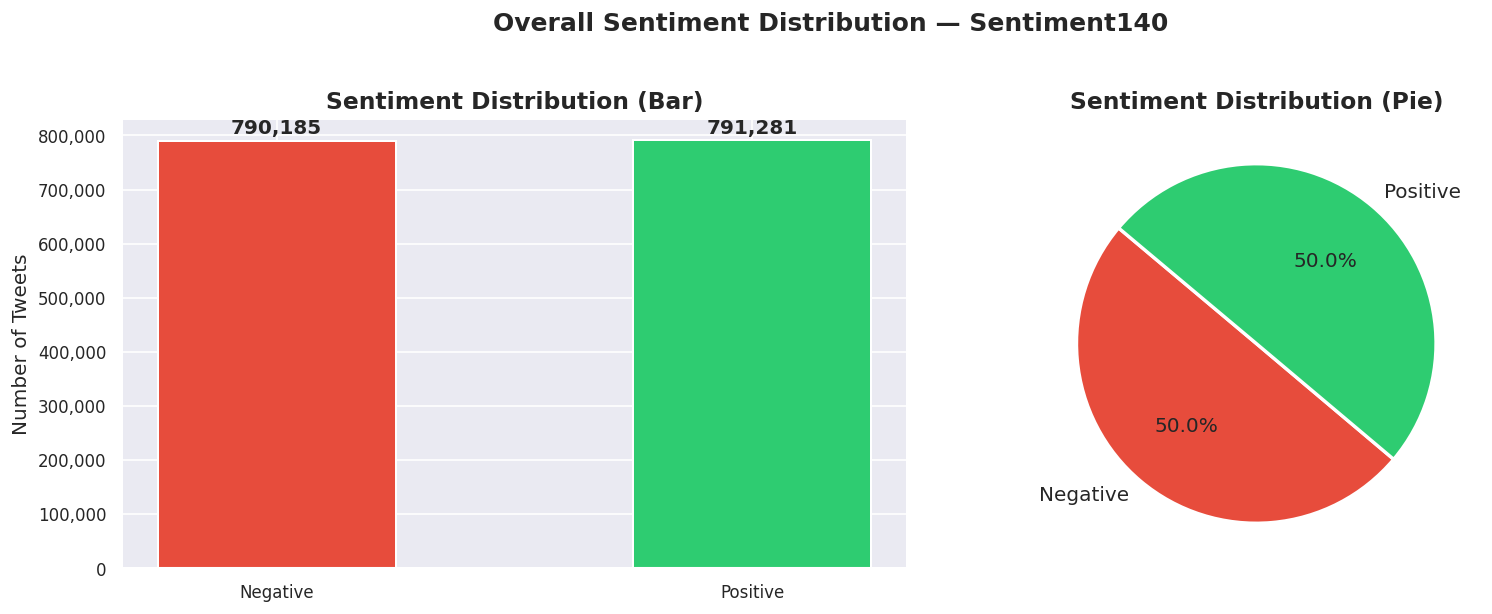

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette   = {'Negative': '#e74c3c', 'Positive': '#2ecc71'}

labels = ['Negative', 'Positive']
counts = [neg_count, pos_count]
colors = [palette['Negative'], palette['Positive']]

# Bar chart
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f'{val:,}', ha='center', va='bottom', fontweight='bold'
    )
axes[0].set_title('Sentiment Distribution (Bar)', fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# Pie chart
axes[1].pie(
    counts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
axes[1].set_title('Sentiment Distribution (Pie)', fontweight='bold')

plt.suptitle('Overall Sentiment Distribution — Sentiment140',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_sentiment_distribution.png', bbox_inches='tight')
plt.show()

### 5.2 Tweet Length Distribution by Sentiment

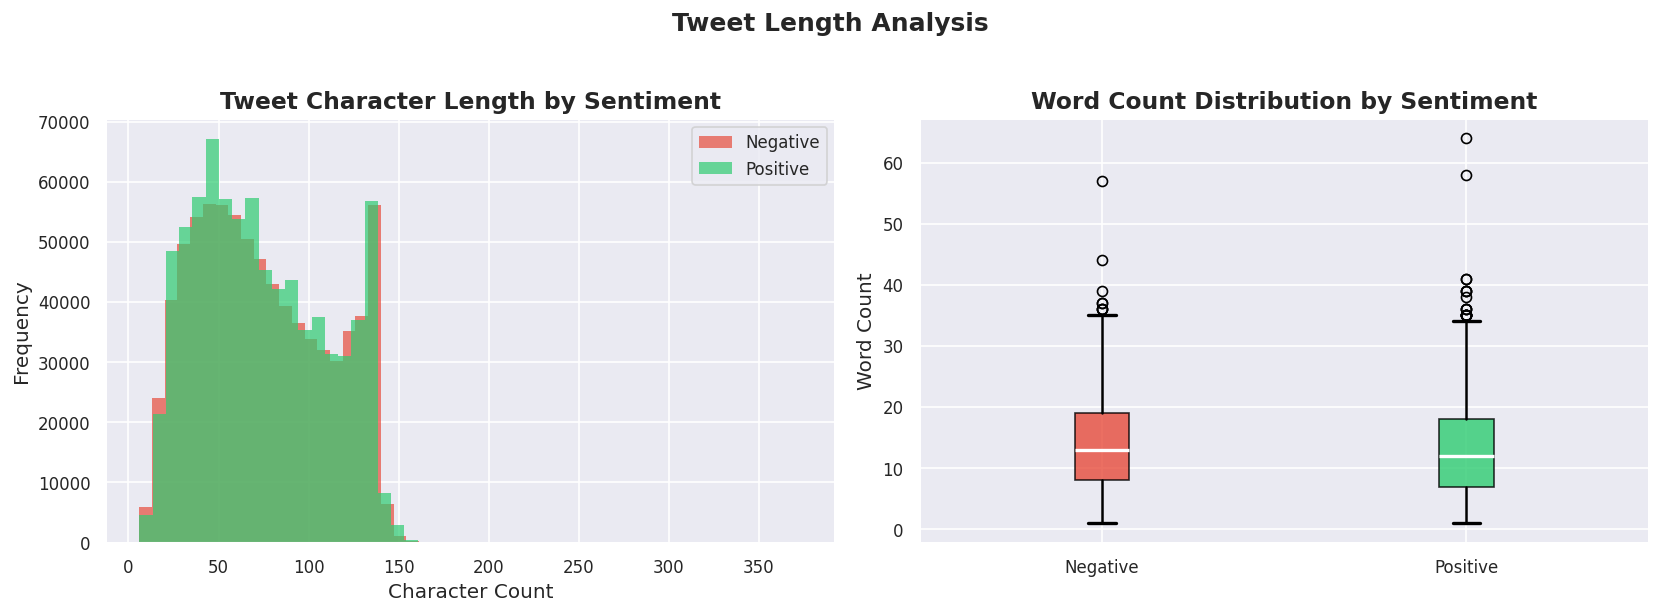

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

neg_lengths    = []
pos_lengths    = []
neg_word_count = []
pos_word_count = []

for tlen, wc, s in zip(df['tweet_length'], df['word_count'], df['sentiment']):
    if s == 0:
        neg_lengths.append(tlen)
        neg_word_count.append(wc)
    else:
        pos_lengths.append(tlen)
        pos_word_count.append(wc)

# Character length histogram
axes[0].hist(neg_lengths, bins=50, alpha=0.7,
             color=palette['Negative'], label='Negative', edgecolor='none')
axes[0].hist(pos_lengths, bins=50, alpha=0.7,
             color=palette['Positive'], label='Positive', edgecolor='none')
axes[0].set_title('Tweet Character Length by Sentiment', fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count box plot
bp = axes[1].boxplot(
    [neg_word_count, pos_word_count],
    labels=['Negative', 'Positive'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=2)
)
for patch, color in zip(bp['boxes'], [palette['Negative'], palette['Positive']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('Word Count Distribution by Sentiment', fontweight='bold')
axes[1].set_ylabel('Word Count')

plt.suptitle('Tweet Length Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_02_tweet_length.png', bbox_inches='tight')
plt.show()

### 5.3 Top 20 Words per Sentiment (Bar Charts)

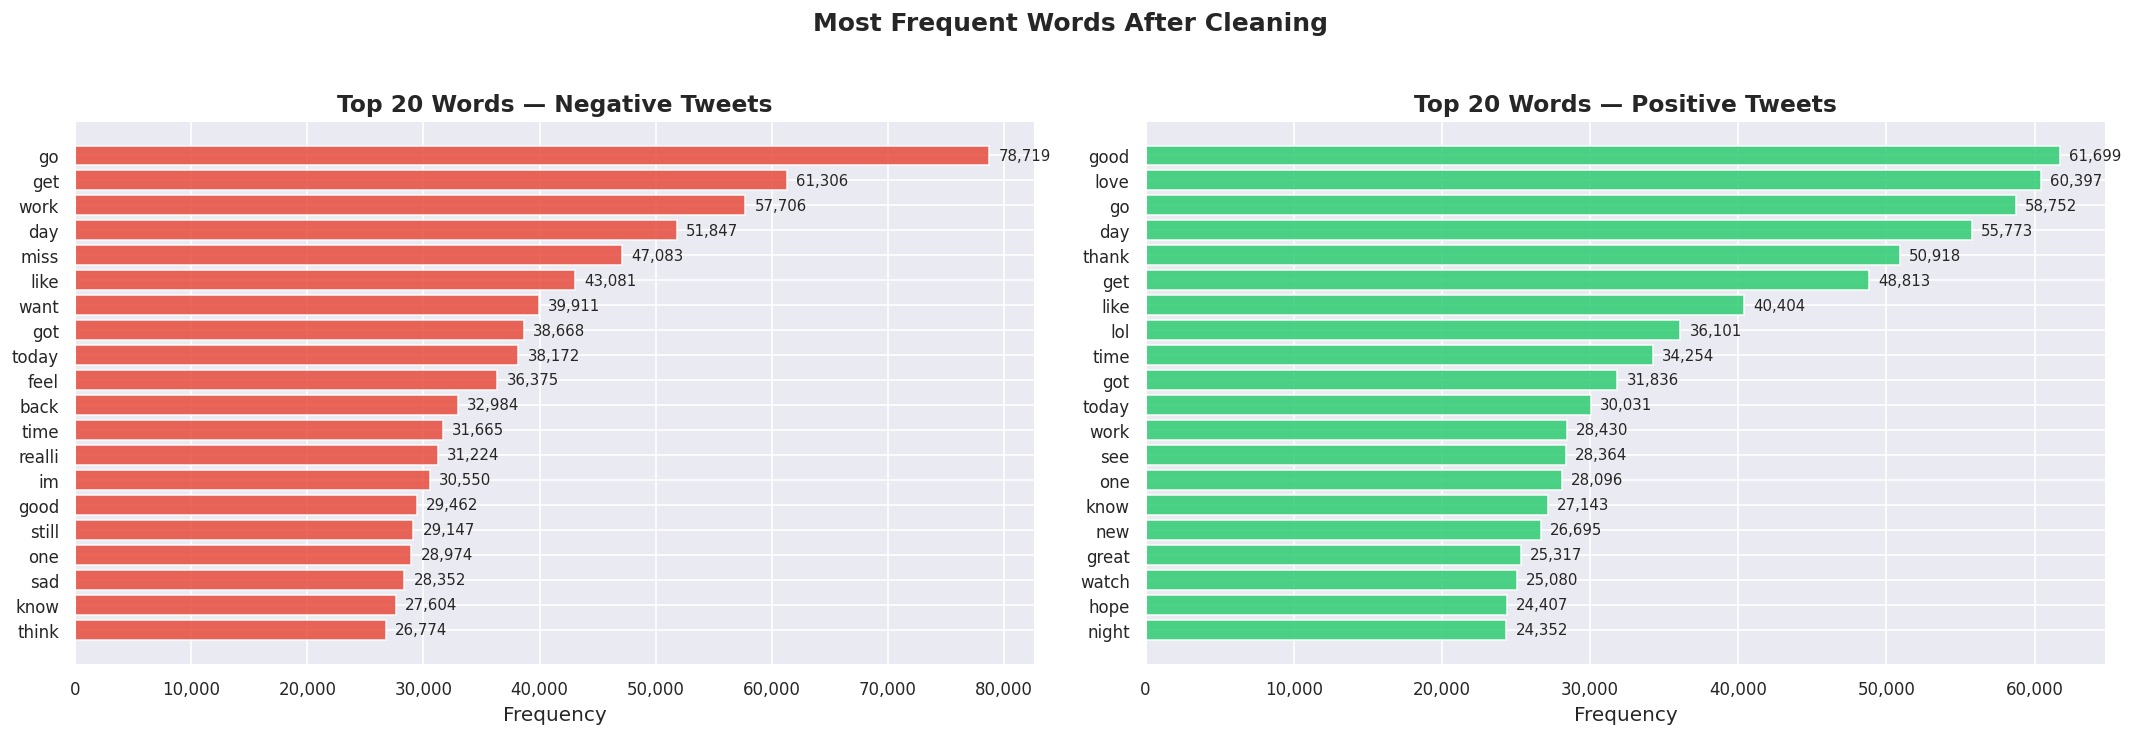

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, word_list, label, color in [
    (axes[0], neg_words, 'Negative', '#e74c3c'),
    (axes[1], pos_words, 'Positive', '#2ecc71'),
]:
    # Reverse for horizontal bar (highest at top)
    words_rev  = [w for w, _ in word_list[::-1]]
    counts_rev = [c for _, c in word_list[::-1]]

    bars = ax.barh(words_rev, counts_rev, color=color, alpha=0.85, edgecolor='white')
    max_c = 0
    for c in counts_rev:
        if c > max_c:
            max_c = c

    for bar, val in zip(bars, counts_rev):
        ax.text(
            bar.get_width() + max_c * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9
        )

    ax.set_title(f'Top 20 Words — {label} Tweets', fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

plt.suptitle('Most Frequent Words After Cleaning',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_03_top_words.png', bbox_inches='tight')
plt.show()

### 5.4 Tweets by Hour of Day

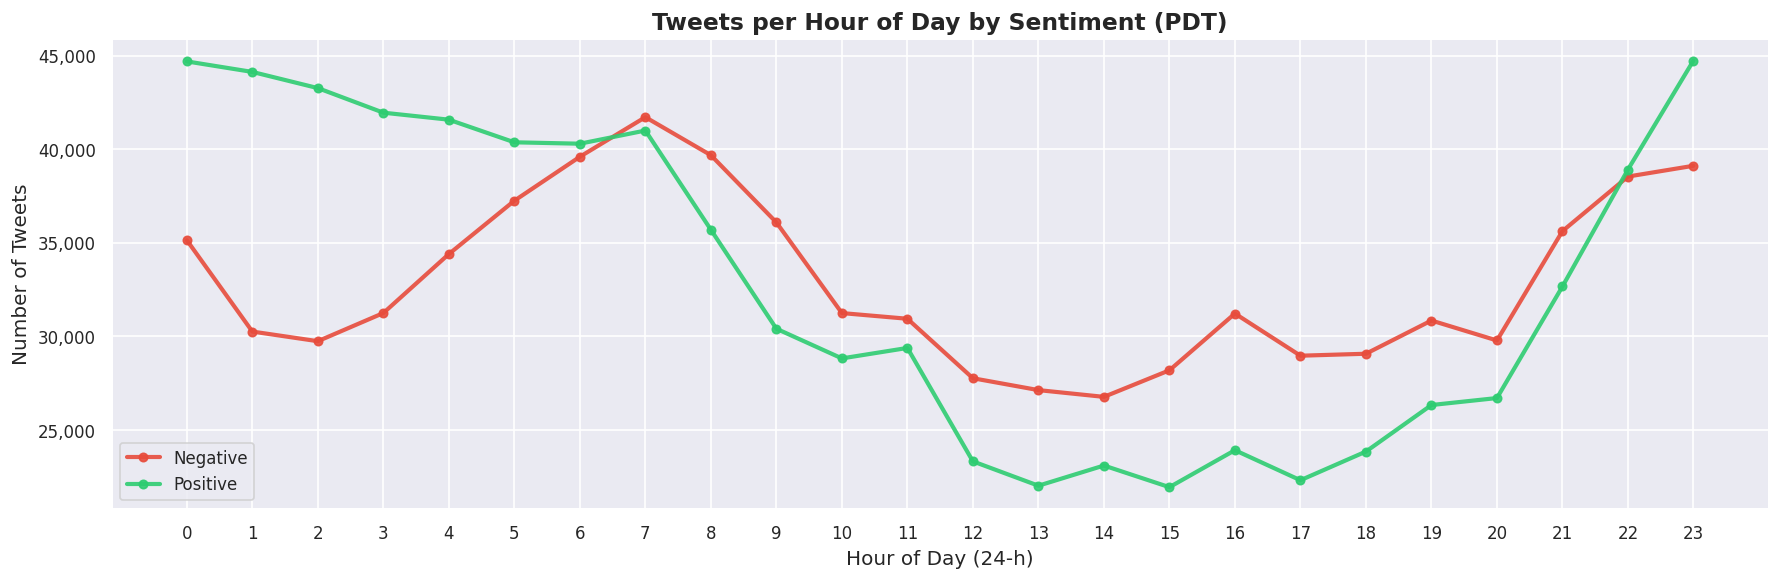

In [11]:
# Build hour frequency tables manually
neg_hourly = {}
pos_hourly = {}
for h in range(0, 24):
    neg_hourly[h] = 0
    pos_hourly[h] = 0

for h, s in zip(df['hour'], df['sentiment']):
    if h != h:   # NaN guard
        continue
    hour_int = int(h)
    if s == 0:
        neg_hourly[hour_int] += 1
    else:
        pos_hourly[hour_int] += 1

hours = list(range(0, 24))
neg_hourly_vals = [neg_hourly[h] for h in hours]
pos_hourly_vals = [pos_hourly[h] for h in hours]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(hours, neg_hourly_vals, marker='o', linewidth=2.5, markersize=5,
        color=palette['Negative'], label='Negative', alpha=0.9)
ax.plot(hours, pos_hourly_vals, marker='o', linewidth=2.5, markersize=5,
        color=palette['Positive'], label='Positive', alpha=0.9)

ax.set_title('Tweets per Hour of Day by Sentiment (PDT)', fontweight='bold')
ax.set_xlabel('Hour of Day (24-h)')
ax.set_ylabel('Number of Tweets')
ax.set_xticks(hours)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

plt.tight_layout()
plt.savefig('plot_05_tweets_by_hour.png', bbox_inches='tight')
plt.show()

### 5.5 Tweets by Month

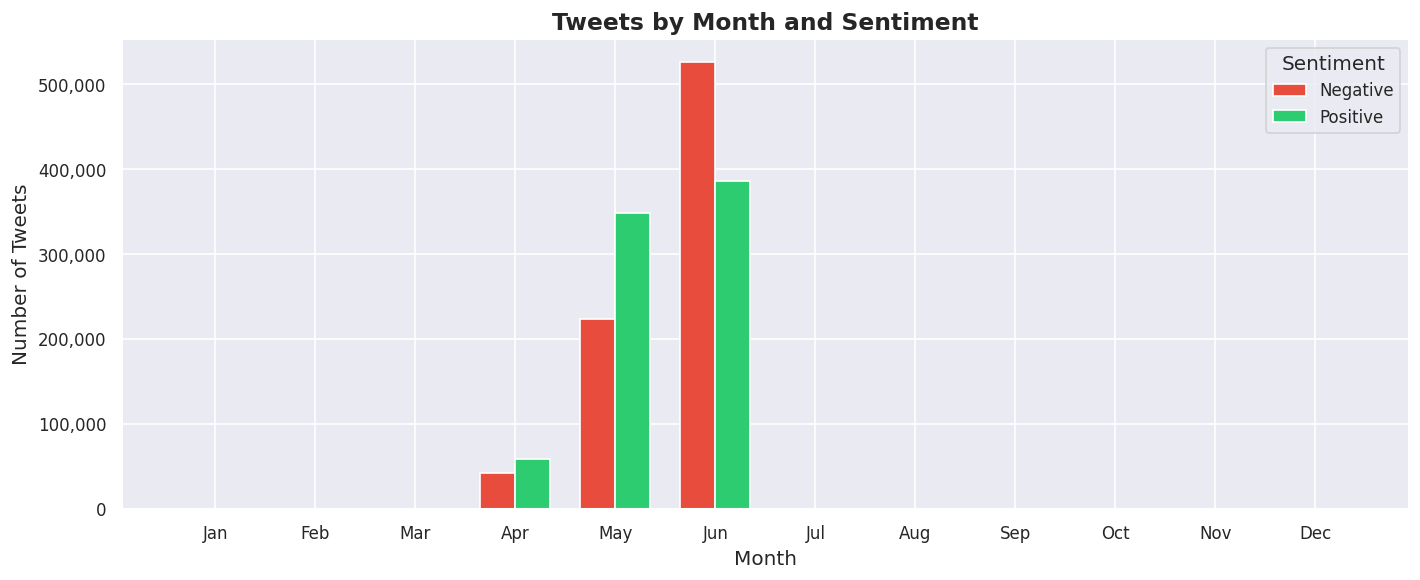

In [12]:
import calendar

# Build month frequency tables manually
months = list(range(1, 13))
neg_monthly = {}
pos_monthly = {}
for m in months:
    neg_monthly[m] = 0
    pos_monthly[m] = 0

for m, s in zip(df['month'], df['sentiment']):
    if m != m:
        continue
    m_int = int(m)
    if s == 0:
        neg_monthly[m_int] += 1
    else:
        pos_monthly[m_int] += 1

month_labels = [calendar.month_abbr[m] for m in months]
neg_m_vals   = [neg_monthly[m] for m in months]
pos_m_vals   = [pos_monthly[m] for m in months]

# Position bars side by side
bar_width = 0.35
x     = [i for i in range(0, len(months))]
x_neg = [xi - bar_width / 2 for xi in x]
x_pos = [xi + bar_width / 2 for xi in x]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_neg, neg_m_vals, width=bar_width,
       color=palette['Negative'], edgecolor='white', label='Negative')
ax.bar(x_pos, pos_m_vals, width=bar_width,
       color=palette['Positive'], edgecolor='white', label='Positive')

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_title('Tweets by Month and Sentiment', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Tweets')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Sentiment')

plt.tight_layout()
plt.savefig('plot_06_tweets_by_month.png', bbox_inches='tight')
plt.show()

### 5.6 Clean Word Count Distribution (KDE)

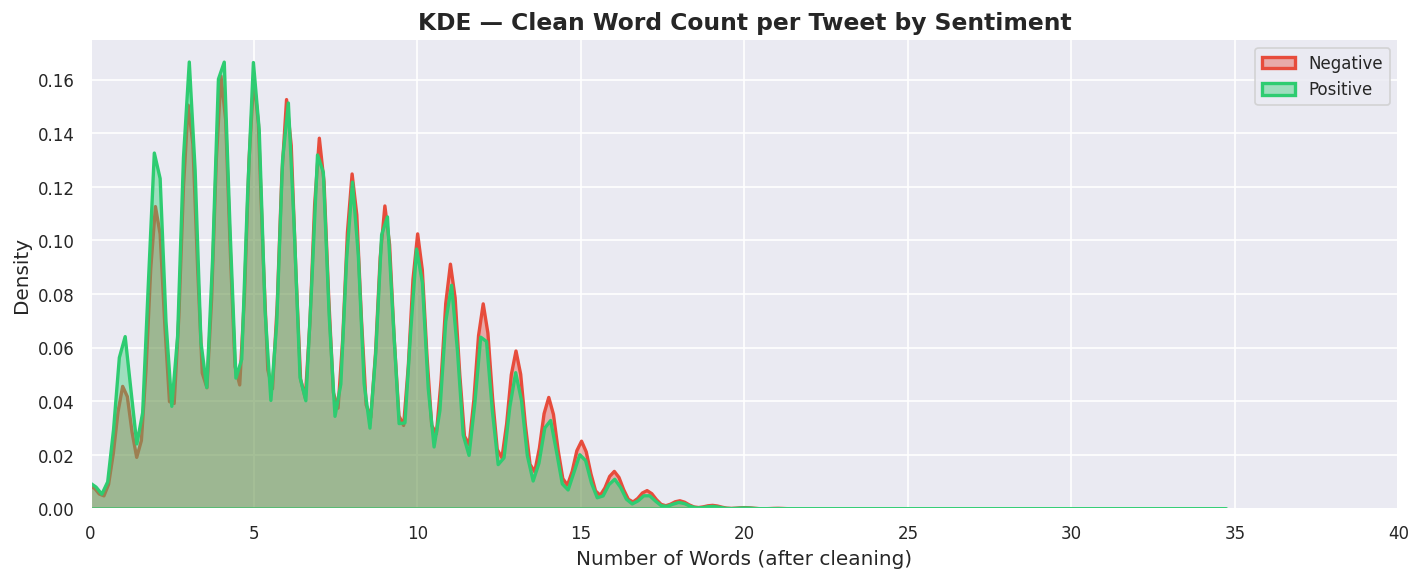

In [13]:
neg_cwc = []
pos_cwc = []
for cwc, s in zip(df['clean_word_count'], df['sentiment']):
    if s == 0:
        neg_cwc.append(cwc)
    else:
        pos_cwc.append(cwc)

fig, ax = plt.subplots(figsize=(12, 5))

sns.kdeplot(neg_cwc, ax=ax, fill=True, alpha=0.4,
            color=palette['Negative'], label='Negative', linewidth=2)
sns.kdeplot(pos_cwc, ax=ax, fill=True, alpha=0.4,
            color=palette['Positive'], label='Positive', linewidth=2)

ax.set_title('KDE — Clean Word Count per Tweet by Sentiment', fontweight='bold')
ax.set_xlabel('Number of Words (after cleaning)')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(0, 40)

plt.tight_layout()
plt.savefig('plot_07_kde_word_count.png', bbox_inches='tight')
plt.show()

### 5.7 Correlation Heatmap (Numeric Features)

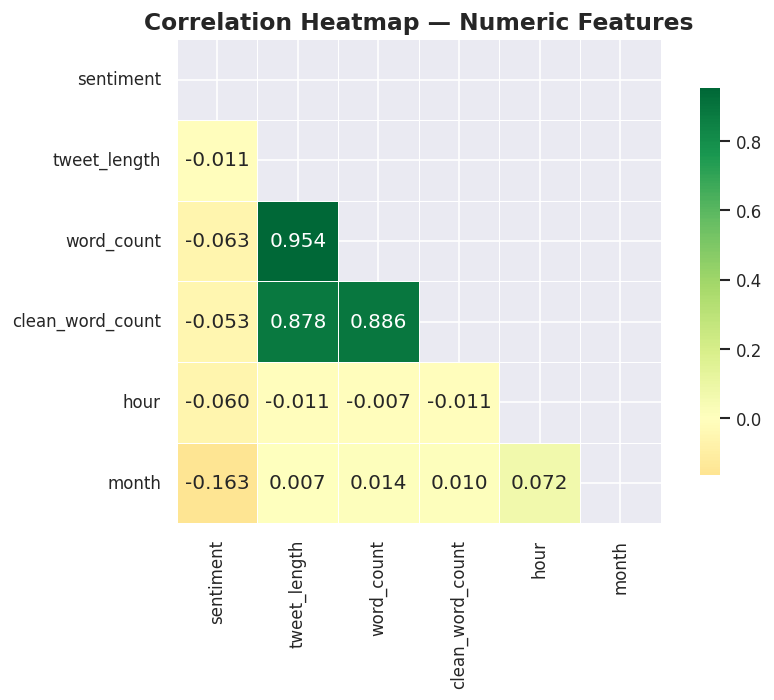

In [14]:
numeric_cols = ['sentiment', 'tweet_length', 'word_count', 'clean_word_count', 'hour', 'month']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    square=True, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_08_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 5.8 Top Users by Tweet Count

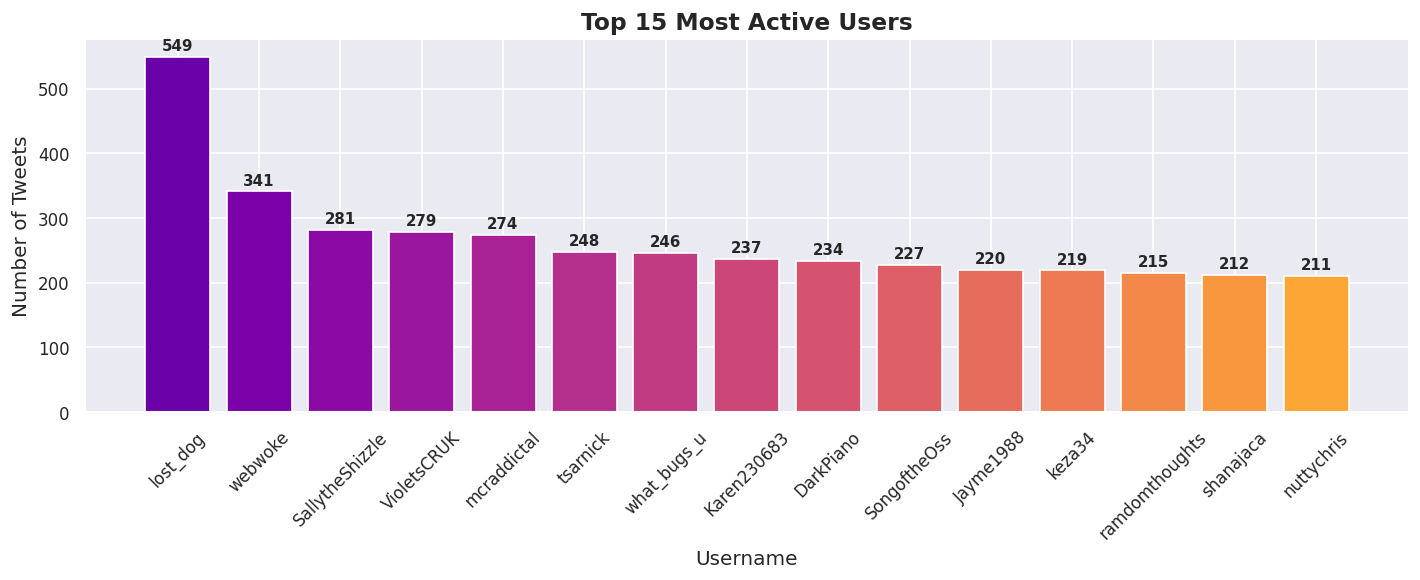

In [15]:
# Build user frequency dict manually
user_freq = {}
for user in df['user']:
    if user in user_freq:
        user_freq[user] += 1
    else:
        user_freq[user] = 1

# Manual selection sort to extract top 15
user_items = [[k, v] for k, v in user_freq.items()]
for i in range(0, 15):
    max_idx = i
    for j in range(i + 1, len(user_items)):
        if user_items[j][1] > user_items[max_idx][1]:
            max_idx = j
    user_items[i], user_items[max_idx] = user_items[max_idx], user_items[i]

top_users   = [row[0] for row in user_items[:15]]
top_ucounts = [row[1] for row in user_items[:15]]

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = plt.cm.plasma(np.linspace(0.2, 0.8, 15))
bars = ax.bar(top_users, top_ucounts, color=bar_colors, edgecolor='white')

max_uc = 0
for c in top_ucounts:
    if c > max_uc:
        max_uc = c

for bar, val in zip(bars, top_ucounts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_uc * 0.01,
        str(val), ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Top 15 Most Active Users', fontweight='bold')
ax.set_xlabel('Username')
ax.set_ylabel('Number of Tweets')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plot_09_top_users.png', bbox_inches='tight')
plt.show()

---
## 6. TF-IDF

In [16]:
df.head()

,date,user,text,sentiment,sentiment_label,month,hour,clean_text,tweet_length,word_count,clean_word_count
0,2009-04-06 22:19:45,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,Negative,4,22,bummer shoulda got david carr third day,115,19,7
1,2009-04-06 22:19:49,scotthamilton,is upset that he can't update his Facebook by ...,0,Negative,4,22,upset updat facebook text might cri result sch...,111,21,11
2,2009-04-06 22:19:53,mattycus,@Kenichan I dived many times for the ball. Man...,0,Negative,4,22,dive mani time ball manag save rest go bound,89,18,9
3,2009-04-06 22:19:57,ElleCTF,my whole body feels itchy and like its on fire,0,Negative,4,22,whole bodi feel itchi like fire,47,10,6
4,2009-04-06 22:19:57,Karoli,"@nationwideclass no, it's not behaving at all....",0,Negative,4,22,behav mad see,111,21,3


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])
Y = df['sentiment'].values



---
## 7. KNN + Naïve Bayes Classification

**Person 3** — KNN + Naïve Bayes models

This section trains two classical text classifiers on the TF-IDF features built above:

| Model | Why it suits text |
|-------|-------------------|
| **K-Nearest Neighbours (KNN)** | Cosine similarity between TF-IDF vectors places semantically close tweets together |
| **Multinomial Naïve Bayes** | Natural fit for bag-of-words / TF-IDF: models word-count likelihoods per class |

### 7.1 Train / Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y          # keep class balance in both splits
)

print('Train size:', X_train.shape[0])
print('Test  size:', X_test.shape[0])

Train size: 1265172
Test  size: 316294


### 7.2 K-Nearest Neighbours (KNN)

#### 7.2.0 Dimensionality Reduction with TruncatedSVD (LSA)

The full TF-IDF matrix has tens of thousands of features, which makes KNN very slow
(it computes distances to every training point at prediction time).
**TruncatedSVD** (Latent Semantic Analysis) compresses the sparse TF-IDF vectors down to
a dense low-dimensional representation **before KNN** — drastically cutting distance-computation time
while preserving the most important variance in the data.

> This reduction is applied **only for KNN**. The original  /  (full TF-IDF) are kept
> unchanged for Naïve Bayes and all other cells.


In [19]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# so slicing rows does not reduce the memory SVD needs.
SAMPLE_PER_CLASS = 20_000

# Get the original text + label arrays aligned with the train split
train_idx = np.array(y_train.index if hasattr(y_train, 'index') else range(len(y_train)))

# Use df directly 
neg_rows = df[df['sentiment'] == 0].sample(n=SAMPLE_PER_CLASS, random_state=42)
pos_rows = df[df['sentiment'] == 1].sample(n=SAMPLE_PER_CLASS, random_state=42)
df_knn   = neg_rows._append(pos_rows).sample(frac=1, random_state=42).reset_index(drop=True)

texts_knn = df_knn['clean_text'].values
y_knn_all = df_knn['sentiment'].values

# Split this small sample into train/test
from sklearn.model_selection import train_test_split as tts
texts_tr, texts_te, y_train_knn, y_test_knn = tts(
    texts_knn, y_knn_all, test_size=0.2, random_state=42, stratify=y_knn_all
)

# Build a fresh TF-IDF on this small corpus only
vec_knn = TfidfVectorizer(ngram_range=(1, 2), max_features=30_000, sublinear_tf=True)
X_small_train = vec_knn.fit_transform(texts_tr)
X_small_test  = vec_knn.transform(texts_te)   

print(f'Small TF-IDF train : {X_small_train.shape}')
print(f'Small TF-IDF test  : {X_small_test.shape}')

# TruncatedSVD on the small matrix
N_COMPONENTS = 100
svd        = TruncatedSVD(n_components=N_COMPONENTS, random_state=42, algorithm='randomized')
normalizer = Normalizer(copy=False)

print(f'Running TruncatedSVD ({N_COMPONENTS} components)...')
X_train_knn = normalizer.fit_transform(svd.fit_transform(X_small_train))
X_test_knn  = normalizer.transform(svd.transform(X_small_test))

explained = svd.explained_variance_ratio_.sum()
print(f'Reduced train : {X_train_knn.shape}')
print(f'Reduced test  : {X_test_knn.shape}')
print(f'Variance kept : {explained*100:.1f}%')


Small TF-IDF train : (32000, 30000)
Small TF-IDF test  : (8000, 30000)
Running TruncatedSVD (100 components)...
Reduced train : (32000, 100)
Reduced test  : (8000, 100)
Variance kept : 13.9%


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Train KNN ---
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    algorithm='ball_tree',
    n_jobs=-1
)
knn.fit(X_train_knn, y_train_knn)

# --- Predict ---
y_pred_knn = knn.predict(X_test_knn)

# --- Metrics ---
knn_acc = accuracy_score(y_test_knn, y_pred_knn)
print(f'KNN Accuracy: {knn_acc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_knn, y_pred_knn, target_names=['Negative', 'Positive']))


KNN Accuracy: 0.6544

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.64      0.65      4000
    Positive       0.65      0.67      0.66      4000

    accuracy                           0.65      8000
   macro avg       0.65      0.65      0.65      8000
weighted avg       0.65      0.65      0.65      8000



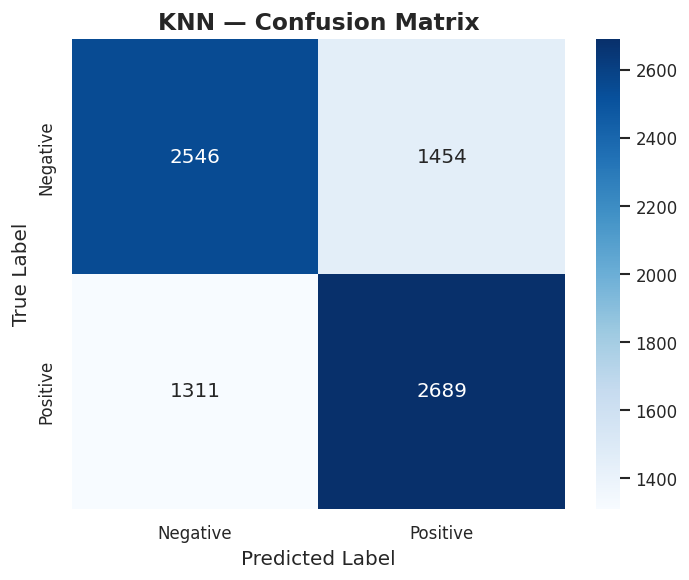

In [21]:
# --- Confusion Matrix — KNN ---
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_knn, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=ax
)
ax.set_title('KNN — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

#### 7.2.1 Choosing *k* — Elbow Plot

We sweep `k` from 1 to 19 (odd values only to avoid ties) and record test accuracy.

  k= 1  accuracy=0.6179
  k= 3  accuracy=0.6386
  k= 5  accuracy=0.6544
  k= 7  accuracy=0.6597
  k= 9  accuracy=0.6616
  k=11  accuracy=0.6639
  k=13  accuracy=0.6651
  k=15  accuracy=0.6663
  k=17  accuracy=0.6674
  k=19  accuracy=0.6704


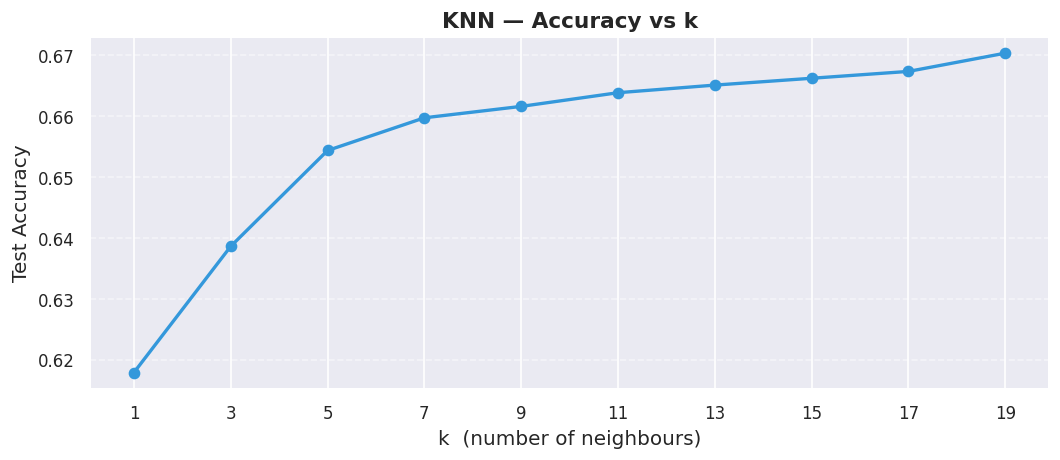


Best k = 19  (accuracy = 0.6704)


In [22]:
k_values  = list(range(1, 20, 2))   # 1, 3, 5, ..., 19
k_acc     = []

for k in k_values:
    clf = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',
        algorithm='ball_tree',
        n_jobs=-1
    )
    clf.fit(X_train_knn, y_train_knn)
    acc = accuracy_score(y_test_knn, clf.predict(X_test_knn))
    k_acc.append(acc)
    print(f'  k={k:2d}  accuracy={acc:.4f}')

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_values, k_acc, marker='o', color='#3498db', linewidth=2)
ax.set_xlabel('k  (number of neighbours)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KNN — Accuracy vs k', fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_k   = k_values[int(np.argmax(k_acc))]
best_acc = max(k_acc)
print(f'\nBest k = {best_k}  (accuracy = {best_acc:.4f})')


### 7.3 Naïve Bayes Classifier

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MaxAbsScaler

# TF-IDF values can be negative after sublinear_tf, scale to [0, 1] for MultinomialNB
scaler   = MaxAbsScaler()
X_train_nb = scaler.fit_transform(X_train)
X_test_nb  = scaler.transform(X_test)

# --- Train Naïve Bayes ---
nb_clf = MultinomialNB(alpha=1.0)   
nb_clf.fit(X_train_nb, y_train)

# --- Predict ---
y_pred_nb = nb_clf.predict(X_test_nb)

# --- Metrics ---
nb_acc = accuracy_score(y_test, y_pred_nb)
print(f'Naïve Bayes Accuracy: {nb_acc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

Naïve Bayes Accuracy: 0.7512

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.76      0.75    158037
    Positive       0.76      0.74      0.75    158257

    accuracy                           0.75    316294
   macro avg       0.75      0.75      0.75    316294
weighted avg       0.75      0.75      0.75    316294



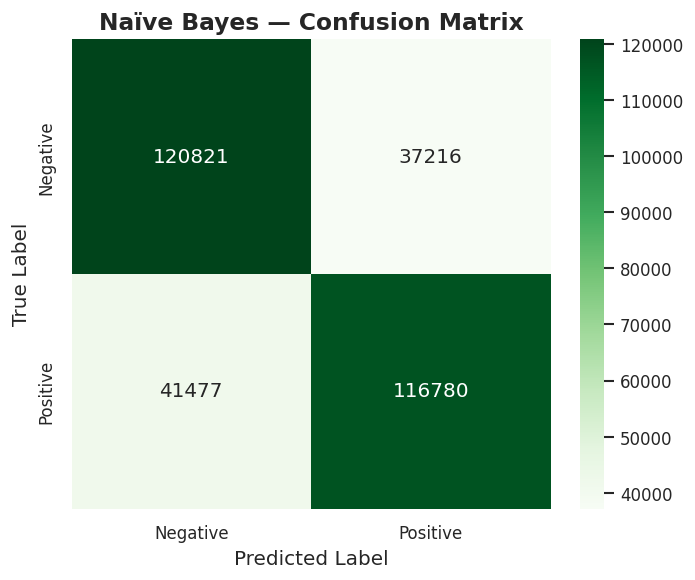

In [24]:
# --- Confusion Matrix — Naïve Bayes ---
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=ax
)
ax.set_title('Naïve Bayes — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

#### 7.3.1 Smoothing Sensitivity — α Sweep

Laplace smoothing (`alpha`) controls how much probability mass is assigned to unseen n-grams.

  alpha=0.01   accuracy=0.7143
  alpha=0.05   accuracy=0.7207
  alpha=0.1    accuracy=0.7253
  alpha=0.3    accuracy=0.7359
  alpha=0.5    accuracy=0.7421
  alpha=1.0    accuracy=0.7512
  alpha=2.0    accuracy=0.7593
  alpha=5.0    accuracy=0.7669


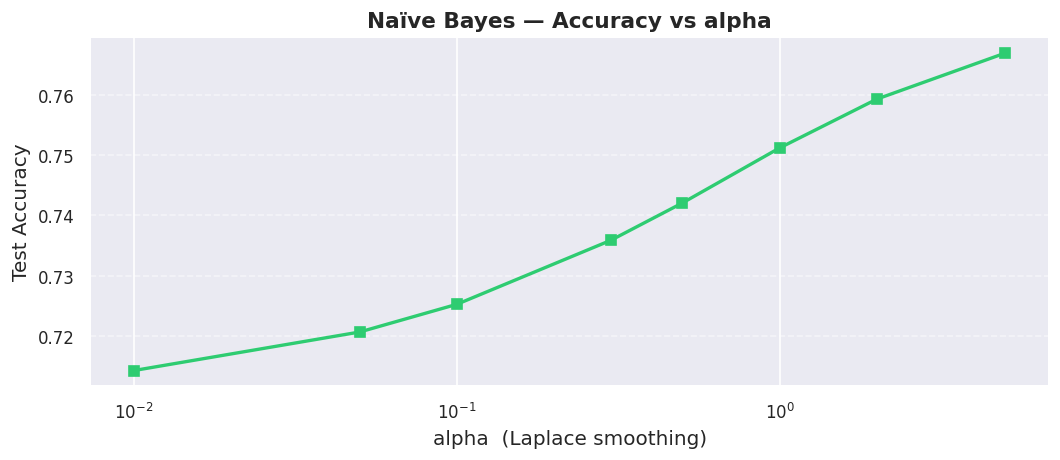


Best alpha = 5.0  (accuracy = 0.7669)


In [25]:
alphas   = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]
nb_accs  = []

for a in alphas:
    clf = MultinomialNB(alpha=a)
    clf.fit(X_train_nb, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_nb))
    nb_accs.append(acc)
    print(f'  alpha={a:<5}  accuracy={acc:.4f}')

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alphas, nb_accs, marker='s', color='#2ecc71', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('alpha  (Laplace smoothing)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Naïve Bayes — Accuracy vs alpha', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_alpha = alphas[int(np.argmax(nb_accs))]
best_nb_acc = max(nb_accs)
print(f'\nBest alpha = {best_alpha}  (accuracy = {best_nb_acc:.4f})')

### 7.4 Model Comparison

             Accuracy  Precision  Recall  F1-Score
KNN            0.6544     0.6546  0.6544    0.6543
Naïve Bayes    0.7512     0.7514  0.7512    0.7512


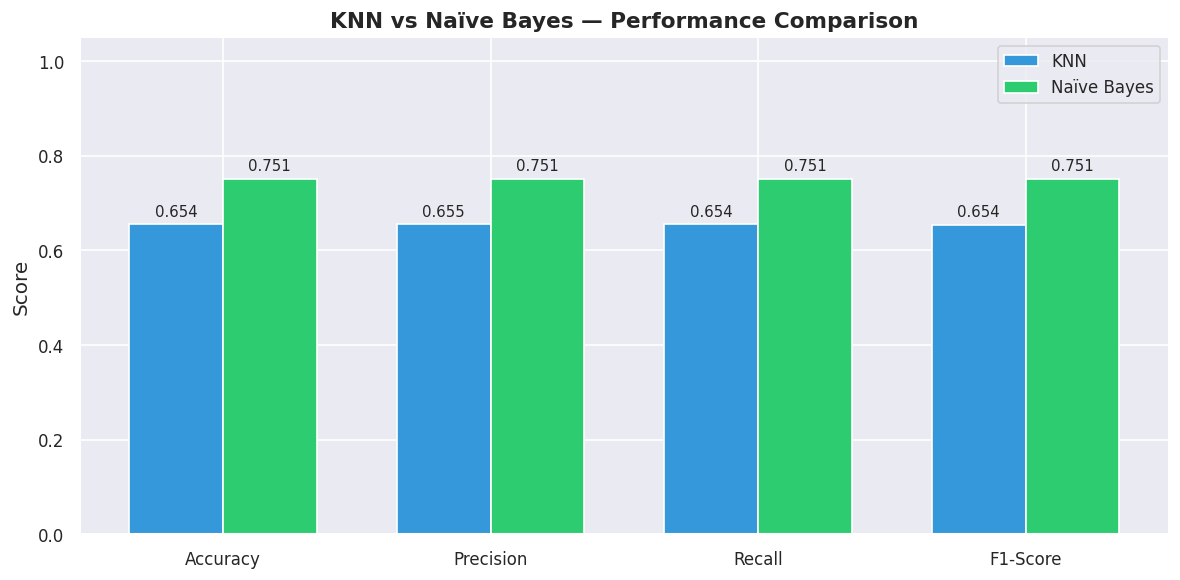

In [26]:
from sklearn.metrics import f1_score, precision_score, recall_score

# KNN is evaluated against y_test_knn (8k sample)
# Naïve Bayes is evaluated against y_test (full test set)
results = {
    'KNN': {
        'Accuracy' : accuracy_score(y_test_knn, y_pred_knn),
        'Precision': precision_score(y_test_knn, y_pred_knn, average='weighted'),
        'Recall'   : recall_score(y_test_knn, y_pred_knn, average='weighted'),
        'F1-Score' : f1_score(y_test_knn, y_pred_knn, average='weighted'),
    },
    'Naïve Bayes': {
        'Accuracy' : accuracy_score(y_test, y_pred_nb),
        'Precision': precision_score(y_test, y_pred_nb, average='weighted'),
        'Recall'   : recall_score(y_test, y_pred_nb, average='weighted'),
        'F1-Score' : f1_score(y_test, y_pred_nb, average='weighted'),
    }
}

results_df = pd.DataFrame(results).T
print(results_df.to_string(float_format='{:.4f}'.format))

# --- Side-by-side bar chart ---
metrics = list(results_df.columns)
x       = np.arange(len(metrics))
width   = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, results_df.loc['KNN'],         width, label='KNN',         color='#3498db')
bars2 = ax.bar(x + width/2, results_df.loc['Naïve Bayes'], width, label='Naïve Bayes', color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('KNN vs Naïve Bayes — Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()

for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


---
## 8. Ensemble Models

Total Explained Variance (50 comps): 4.77%


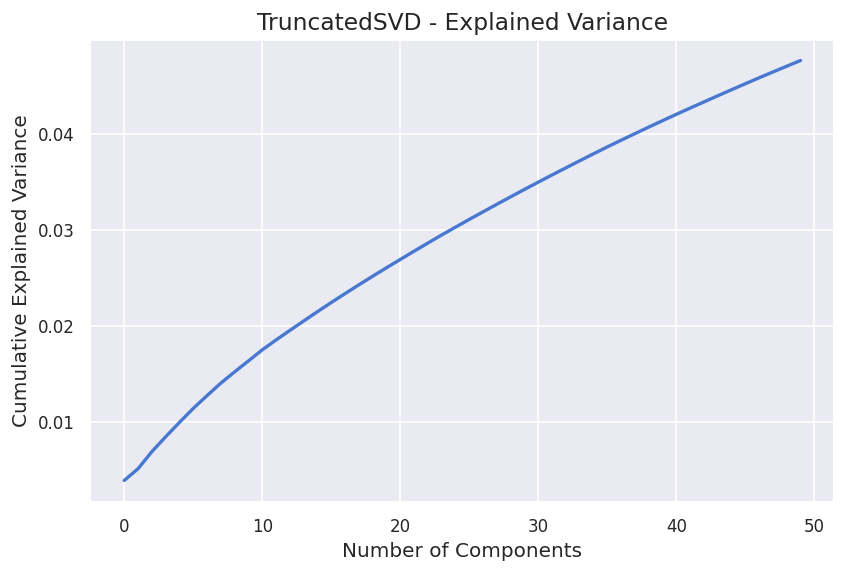

In [27]:
# =========================================
#  Dimensionality Reduction (TruncatedSVD)
# =========================================

from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt

N_COMPONENTS = 50

svd_full = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_train_svd_full = svd_full.fit_transform(X_train)
X_test_svd_full  = svd_full.transform(X_test)

explained_var = svd_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

print(f"Total Explained Variance ({N_COMPONENTS} comps): {cum_var[-1]*100:.2f}%")

# 📊 Plot Explained Variance
plt.figure(figsize=(8,5))
plt.plot(cum_var, linewidth=2)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("TruncatedSVD - Explained Variance")
plt.grid(True)
plt.show()

### 8.1 Random Forest Classifier

Random Forest Accuracy: 0.6979
              precision    recall  f1-score   support

           0       0.71      0.68      0.69    158037
           1       0.69      0.72      0.70    158257

    accuracy                           0.70    316294
   macro avg       0.70      0.70      0.70    316294
weighted avg       0.70      0.70      0.70    316294



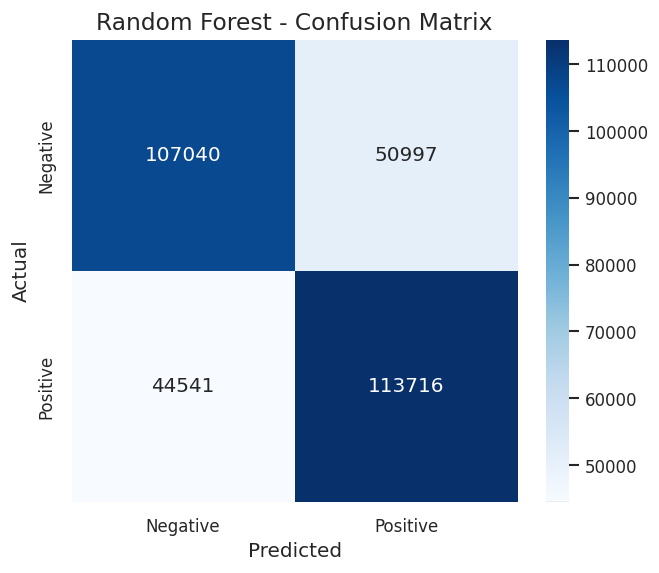

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=15,
    random_state=42,
    max_features='sqrt',
    n_jobs=-1
)

rf.fit(X_train_svd_full, y_train)
y_pred_rf = rf.predict(X_test_svd_full)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(classification_report(y_test, y_pred_rf))

# 📊 Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Parameters: {'n_estimators': 50, 'max_depth': 20}
Tuned RF Accuracy: 0.7106


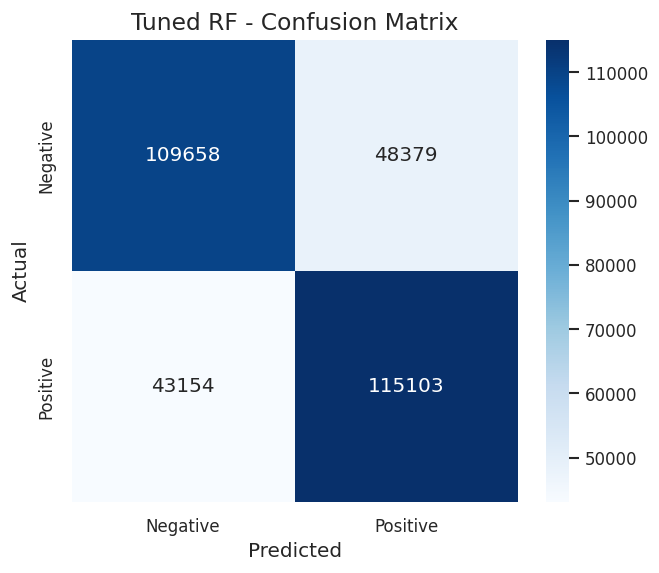

In [29]:
from sklearn.model_selection import RandomizedSearchCV

SAMPLE_SIZE = 100000

idx = np.random.choice(len(X_train_svd_full), SAMPLE_SIZE, replace=False)
X_sample = X_train_svd_full[idx]
y_sample = y_train[idx]

param_dist = {
    'n_estimators': [30, 50, 70],
    'max_depth': [10, 15, 20],
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=2,       
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_rf.fit(X_sample, y_sample)

print("Best Parameters:", random_rf.best_params_)

best_rf = RandomForestClassifier(
    **random_rf.best_params_,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_svd_full, y_train)
y_pred_rf_tuned = best_rf.predict(X_test_svd_full)

rf_tuned_acc = accuracy_score(y_test, y_pred_rf_tuned)
rf_tuned_f1  = f1_score(y_test, y_pred_rf_tuned, average='weighted')

print(f"Tuned RF Accuracy: {rf_tuned_acc:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.title("Tuned RF - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 8.2 XGBoost Classifier 

XGBoost Accuracy: 0.7027
              precision    recall  f1-score   support

           0       0.71      0.69      0.70    158037
           1       0.70      0.72      0.71    158257

    accuracy                           0.70    316294
   macro avg       0.70      0.70      0.70    316294
weighted avg       0.70      0.70      0.70    316294



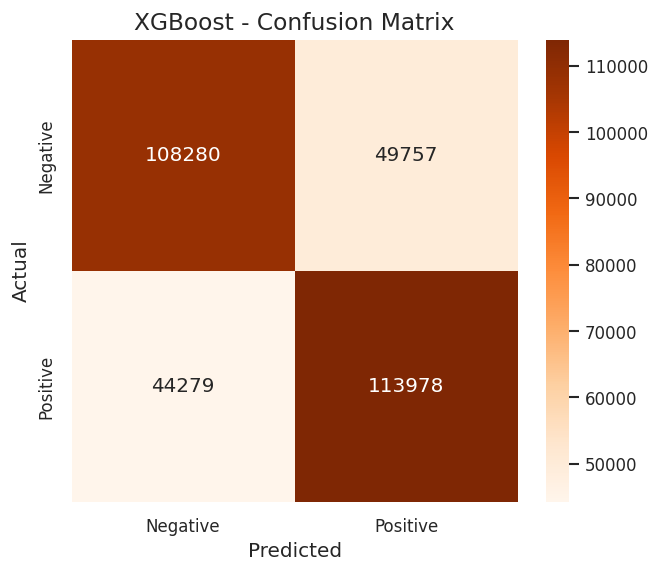

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_svd_full, y_train)
y_pred_xgb = xgb.predict(X_test_svd_full)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print(classification_report(y_test, y_pred_xgb))


cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGB Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}
Tuned XGBoost Accuracy: 0.7051


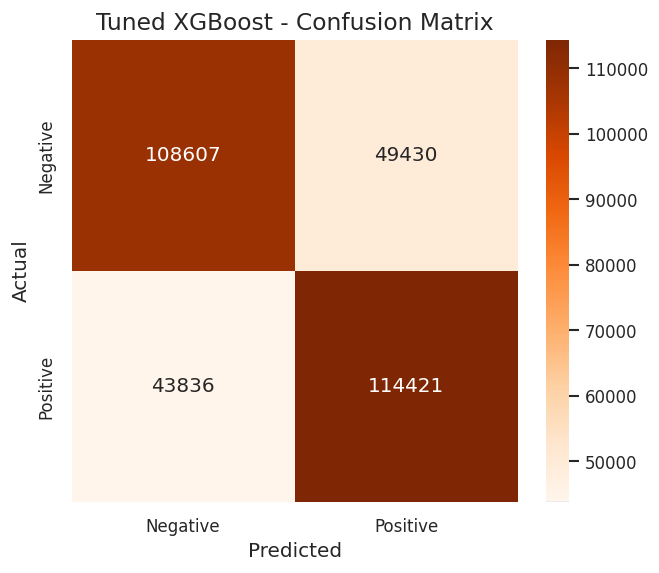

In [31]:
SAMPLE_SIZE = 100000
idx = np.random.choice(len(X_train_svd_full), SAMPLE_SIZE, replace=False)

X_sample = X_train_svd_full[idx]
y_sample = y_train[idx]

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=8,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_xgb.fit(X_sample, y_sample)

print("Best XGB Params:", random_xgb.best_params_)

best_xgb = XGBClassifier(
    **random_xgb.best_params_,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train_svd_full, y_train)

y_pred_xgb_tuned = best_xgb.predict(X_test_svd_full)

xgb_acc_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
xgb_f1_tuned  = f1_score(y_test, y_pred_xgb_tuned, average='weighted')

print(f"Tuned XGBoost Accuracy: {xgb_acc_tuned:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb_tuned)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.title("Tuned XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---
## 9. Final Model Comparison

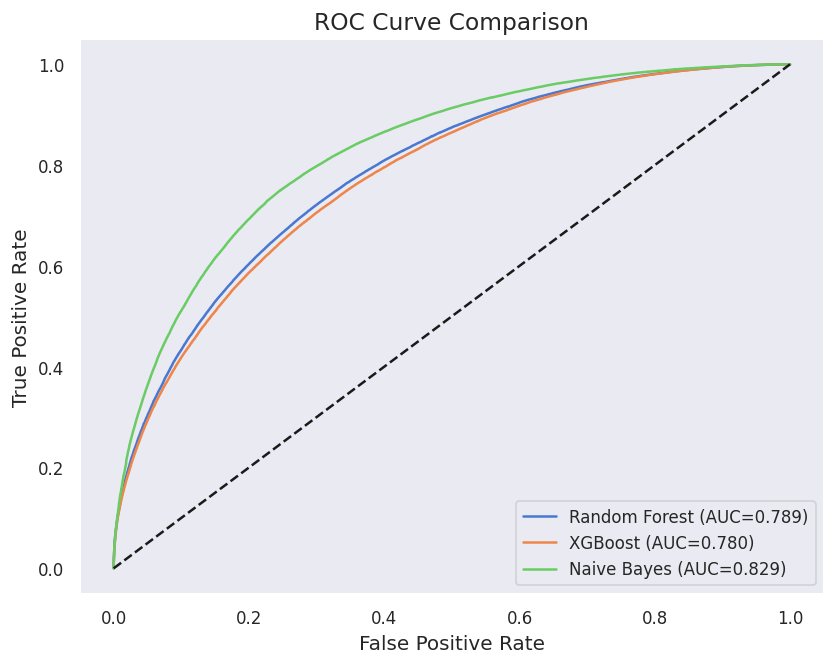

In [32]:
# =========================================
#  ROC Curve
# =========================================

from sklearn.metrics import roc_curve, auc

rf_probs  = best_rf.predict_proba(X_test_svd_full)[:,1]
xgb_probs = xgb.predict_proba(X_test_svd_full)[:,1]
nb_probs  = nb_clf.predict_proba(X_test_nb)[:,1]

# ROC
fpr_rf, tpr_rf, _   = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_nb, tpr_nb, _   = roc_curve(y_test, nb_probs)

auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_nb  = auc(fpr_nb, tpr_nb)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC={auc_nb:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

               Accuracy        F1
KNN            0.654375  0.654265
Naive Bayes    0.751203  0.751160
Random Forest  0.697946  0.697815
RF Tuned       0.710608  0.710526
XGBoost        0.702694  0.702602
XGB Tuned      0.705129  0.705033


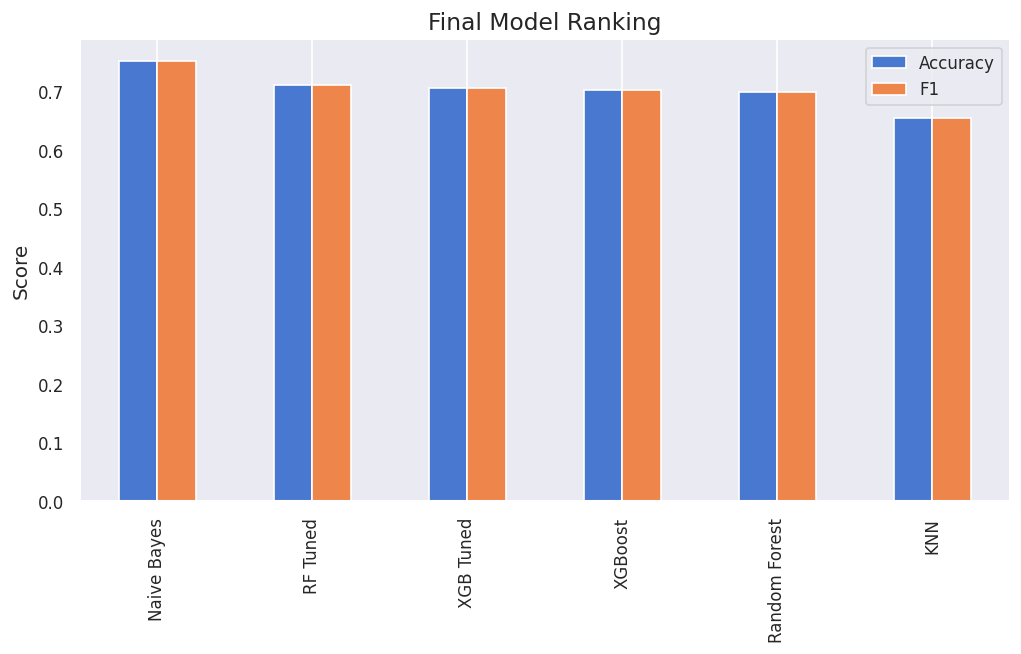

In [33]:
from sklearn.metrics import precision_score, recall_score

results = {
    'KNN': {
        'Accuracy': accuracy_score(y_test_knn, y_pred_knn),
        'F1': f1_score(y_test_knn, y_pred_knn, average='weighted')
    },
    'Naive Bayes': {
        'Accuracy': accuracy_score(y_test, y_pred_nb),
        'F1': f1_score(y_test, y_pred_nb, average='weighted')
    },
    'Random Forest': {
        'Accuracy': rf_acc,
        'F1': rf_f1
    },
    'RF Tuned': {
       'Accuracy': rf_tuned_acc,
        'F1': rf_tuned_f1
    },
    'XGBoost': {
        'Accuracy': xgb_acc,
        'F1': xgb_f1
    },
    'XGB Tuned': {
        'Accuracy': xgb_acc_tuned ,
        'F1': xgb_f1_tuned
    }
}

results_df = pd.DataFrame(results).T
print(results_df)

results_df.sort_values(by='F1', ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Final Model Ranking")
plt.ylabel("Score")
plt.grid(axis='y')
plt.show()